In [1]:
# 수치 계산 및 랜덤 데이터 생성을 위한 라이브러리
import numpy as np

# 데이터 표(DataFrame) 처리를 위한 라이브러리
import pandas as pd

# 데이터 시각화를 위한 그래프 라이브러리
import matplotlib.pyplot as plt

# 프로그램 시작 메시지 출력
print("HomeFit AI Ready 🚀")

HomeFit AI Ready 🚀


In [2]:
# 가짜 데이터 만들기 (연습용)
data = {
    
    # 운동 완료율 (60% ~ 100% 사이 랜덤값 100개 생성)
    "completion": np.random.randint(60, 101, 100),
    
    # 자세 정확도 (50% ~ 100%)
    "pose": np.random.randint(50, 101, 100),
    
    # 운동 연속 수행일수 (1일 ~ 30일)
    "streak": np.random.randint(1, 30, 100),
    
    # 목표 달성률 (40% ~ 100%)
    "goal": np.random.randint(40, 101, 100),
    
    # 운동 시간 (20분 ~ 90분)
    "time": np.random.randint(20, 90, 100),
    
    # 체형 등급 (1 ~ 4 단계)
    "body": np.random.randint(1, 5, 100),
    
    # 운동 포인트 (30 ~ 100점)
    "point": np.random.randint(30, 100, 100)
}

# 생성한 데이터를 Pandas DataFrame(표 형태 데이터)으로 변환
df = pd.DataFrame(data)

# 데이터 상위 5개 행 출력
df.head()

,completion,pose,streak,goal,time,body,point
0,97,76,10,65,65,1,57
1,71,93,22,85,69,2,52
2,65,80,14,85,50,4,97
3,74,57,27,43,52,1,87
4,85,94,25,54,53,3,75


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 입력 / 출력 분리
X = df.drop("point", axis=1)
y = df["point"]

# 학습용 / 테스트용 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 모델 생성
model = RandomForestRegressor()
model.fit(X_train, y_train)

# 예측
pred = model.predict(X_test)

print("오차:", mean_absolute_error(y_test, pred))

오차: 18.963999999999995


In [4]:
# 포인트 공식
# 최종 포인트 =
# (운동완료 × 0.2)
# + (자세정확도 × 0.3)
# + (연속성 × 0.2)
# + (목표달성 × 0.2)
# + (운동시간 × 0.1)

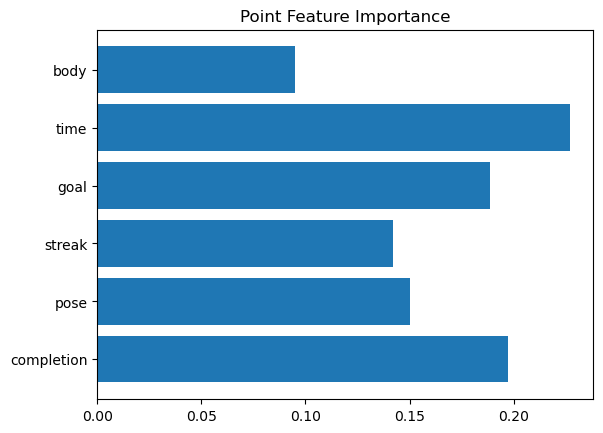

In [5]:
# AI가 어떤 요소를 중요하게 보는지 확인
import matplotlib.pyplot as plt

importance = model.feature_importances_

features = X.columns

plt.barh(features, importance)
plt.title("Point Feature Importance")
plt.show()

In [6]:
# 실전 예측 테스트
sample = pd.DataFrame([{
    "completion": 95,
    "pose": 90,
    "streak": 20,
    "goal": 85,
    "time": 60,
    "body": 2
}])

result = model.predict(sample)

print("예상 포인트:", int(result[0]))

예상 포인트: 67


In [7]:
import joblib

joblib.dump(model, "point_model.pkl")

['point_model.pkl']

In [8]:
import pymysql

conn = pymysql.connect(
    host="localhost",
    user="root",
    password="12345",
    database="homefit",
    charset="utf8"
)

cursor = conn.cursor()

print("DB 연결 성공 🎉")

DB 연결 성공 🎉


In [9]:
user_id = "test_user"

posture = 90
duration = 60
continuity = 15
goal = 80
point = 75

sql = """
INSERT INTO user_points
(user_id, posture_score, duration, continuity, goal_score, total_point)
VALUES (%s,%s,%s,%s,%s,%s)
"""

values = (
    user_id,
    posture,
    duration,
    continuity,
    goal,
    point
)

cursor.execute(sql, values)
conn.commit()

print("저장 완료 ✅")

저장 완료 ✅
